<center>
    <h1>Apurba Koirala</h1>
    <h2> 22BCE3799 </h2>
    <h3> Machine Learning Lab Assessment 2 </h3>
</center>

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_error, root_mean_squared_error
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, RandomizedSearchCV
import math
from scipy.stats import loguniform
from collections import Counter, defaultdict
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

1. 
Implement and demonstrate the FIND-S algorithm for finding the most specific hypothesis
based on a given set of training data samples. Read the training data from a .CSV file.

In [2]:
def find_s(filename):
    data = pd.read_csv(filename)
    attributes = data.iloc[:, :-1].values
    target = data.iloc[:, -1].values

    hypothesis = ['0'] * len(attributes[0])
    for i, val in enumerate(target):
        if val.lower() == 'yes':
            hypothesis = attributes[i].copy()
            break

    for i, val in enumerate(attributes):
        if target[i].lower() == 'yes':
            for j in range(len(hypothesis)):
                if val[j] != hypothesis[j]:
                    hypothesis[j] = '?'

    print('Final Hypothesis: ', hypothesis)

In [4]:
find_s('demo.csv')

Final Hypothesis:  ['Sunny' 'Warm' '?' 'Strong' '?' '?']


2. For a given set of training data examples stored in a .CSV file, implement and demonstrate
the Candidate-Elimination algorithm to output a description of the set of all hypotheses
consistent with the training examples.

In [7]:
def candidate_elimination(filename):
    data = pd.read_csv(filename).astype(str)
    X = data.iloc[:, :-1].values.tolist()
    y = data.iloc[:, -1].str.lower().tolist()

    def consistent(h, x):
        return all(h[i] == '?' or h[i] == x[i] for i in range(len(h)))

    n = len(X[0])
    specific_h = ['0'] * n
    general_h = [['?'] * n]

    for i, label in enumerate(y):
        x_i = X[i]

        if label in {'yes', '1', 'true', 'y'}:
            for j in range(n):
                if specific_h[j] == '0':
                    specific_h[j] = x_i[j]
                elif specific_h[j] != x_i[j]:
                    specific_h[j] = '?'
            general_h = [g for g in general_h if consistent(g, x_i)]

        else:
            new_G = []
            for g in general_h:
                if consistent(g, x_i):
                    for j in range(n):
                        if g[j] == '?' and specific_h[j] != '?' and specific_h[j] != '0':
                            g_new = g.copy()
                            g_new[j] = specific_h[j]
                            if not consistent(g_new, x_i):
                                new_G.append(g_new)
                else:
                    new_G.append(g)
            unique = []
            for g in new_G:
                if g not in unique:
                    unique.append(g)
            def more_general_or_equal(a, b):
                return all(aa == '?' or aa == bb for aa, bb in zip(a, b))
            G_prime = []
            for g in unique:
                if not any((g != h and more_general_or_equal(h, g)) for h in unique):
                    G_prime.append(g)
            general_h = G_prime

    print("Final Specific Hypothesis:", specific_h)
    print("Final General Hypotheses:", general_h)

In [8]:
candidate_elimination('demo.csv')

Final Specific Hypothesis: ['Sunny', 'Warm', '?', 'Strong', '?', '?']
Final General Hypotheses: [['Sunny', '?', '?', '?', '?', '?'], ['?', 'Warm', '?', '?', '?', '?']]


3. Write a python program to demonstrate the working of the Regression models. Use an
appropriate data set for building the regression model and apply this knowledge to classify a
new sample.
- a. Split data into a train and a test split in different ratio’s (like 70% and 30% or 80%
and 20% respectively).
- b. Conduct experiments with simple regression model
- c. For each different ratio of regression model calculate and compare the accuracy
using the performance metrics R-square, MAE, MSE and RMSE.
- d. Create Scatter plot to display the regression line.
- e. Compare the performance results using Matplotlib, plot the performance measure
scores as per your choice like bar chart, box plot etc.

/Users/apurbakoirala/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


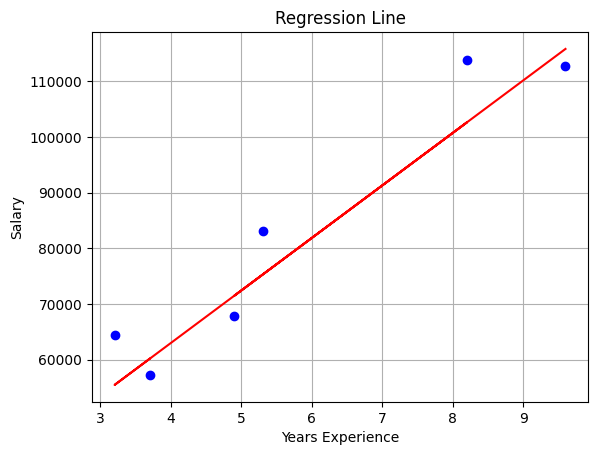

Performance Metrics
R2 score: 0.9024461774180498
MAE: 6286.453830757742
MSE: 49830096.855908334
RMSE: 7059.043621901506


In [14]:
df = pd.read_csv('SimpleLinearRegression.csv')
x = df[['YearsExperience']]
y = df['Salary']

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=42)

model = LinearRegression()
model.fit(x_train, y_train)
y_p = model.predict(x_test)

r2 = r2_score(y_test, y_p)
mae = mean_absolute_error(y_test, y_p)
mse = mean_squared_error(y_test, y_p)
rmse = mean_squared_error(y_test, y_p, squared=False)   # ✅ sklearn way

plt.scatter(x_test, y_test, color='blue')
plt.plot(x_test, y_p, color='red')
plt.title('Regression Line')
plt.xlabel('Years Experience')
plt.ylabel('Salary')
plt.grid(True)
plt.show()

print('Performance Metrics')
print(f'R2 score: {r2}')
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')

4. Write a program to demonstrate the working of the decision tree based ID3 algorithm. Use
an appropriate data set for building the decision tree and apply this knowledge to classify a
new sample.

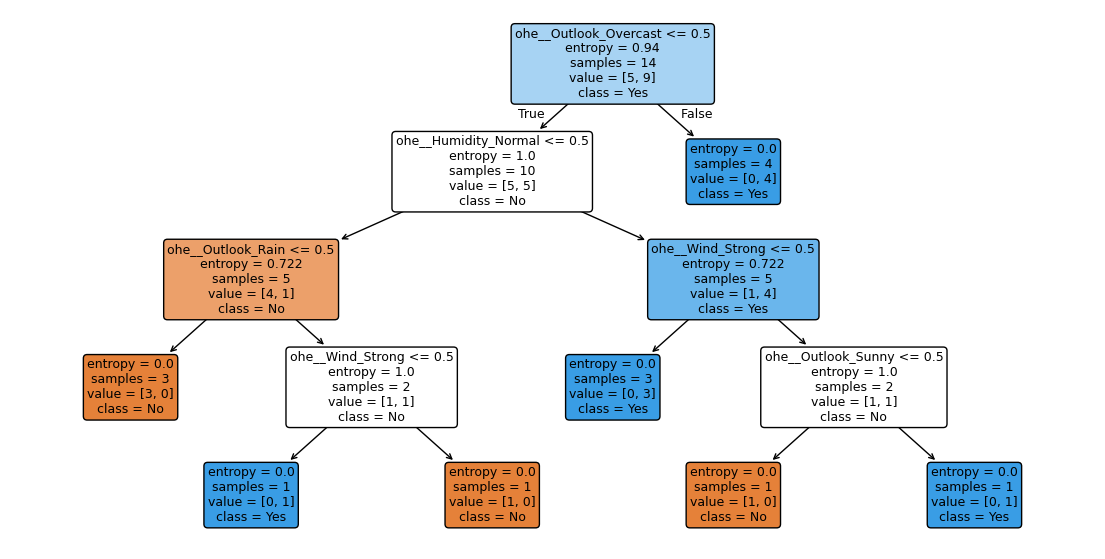

Prediction: No


In [20]:
df = pd.read_csv("playtennis.csv")
X = df.drop(columns=["PlayTennis"])
y = df["PlayTennis"]

pre = ColumnTransformer(
    transformers=[("ohe", OneHotEncoder(handle_unknown="ignore"), X.columns)],
    remainder="drop"
)

pipe = Pipeline([
    ("pre", pre),
    ("clf", DecisionTreeClassifier(criterion="entropy", random_state=42))
])

pipe.fit(X, y)

clf = pipe.named_steps["clf"]
feature_names = pipe.named_steps["pre"].get_feature_names_out()

plt.figure(figsize=(14,7))
plot_tree(
    clf,
    feature_names=feature_names,
    class_names=clf.classes_.astype(str),
    filled=True,
    rounded=True,
    fontsize=9
)
plt.show()

# classify a new sample (example)
sample = {"Outlook":"Sunny","Temperature":"Cool","Humidity":"High","Wind":"Strong"}
print("Prediction:", pipe.predict(pd.DataFrame([sample]))[0])

5. Write a program to implement k-Nearest Neighbour algorithm to classify the iris data set.
Print both correct and wrong predictions.

In [32]:
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="target")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

param_grid = {
    "knn__n_neighbors": [3,5,7,9,11,13,15],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"],
    "knn__leaf_size": [15, 30, 45]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(pipe, param_grid=param_grid, cv=cv, n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("CV best score:", grid.best_score_)
y_pred = grid.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred, target_names=iris.target_names))

Best params: {'knn__leaf_size': 15, 'knn__metric': 'euclidean', 'knn__n_neighbors': 3, 'knn__weights': 'uniform'}
CV best score: 0.9666666666666668
Test accuracy: 0.9333333333333333

Confusion matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]

Classification report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



6. Train SVM classifier using sklearn digits dataset( i.e from sklearn datasets import load_digits)
and then
- a. Measure accuracy of your model using different kernels such as rbf and linear.
- b. Tune your model further using regularization and gamma parameters and try to
come up highest accuracy score.
- c. Use 80% of samples as training data size.

In [38]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf"))
])

param_dist = {
    "svc__C": loguniform(1e-2, 1e2),
    "svc__gamma": loguniform(1e-4, 1e0)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rs = RandomizedSearchCV(
    pipe, param_distributions=param_dist,
    n_iter=40, cv=cv, n_jobs=-1, random_state=42
)
rs.fit(X_train, y_train)

print("Best params:", rs.best_params_)
print("CV best score:", rs.best_score_)
y_pred = rs.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))

Best params: {'svc__C': 0.6672367170464207, 'svc__gamma': 0.13826232179369857}
CV best score: 0.975
Test accuracy: 0.9666666666666667

Confusion matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

